# Scaler를 사용해야 하는 이유
: 다차원의 변수 값을 비교분석하기 쉽게 만듬  
: 단위가 다르기 때문에 통일

# Scaler의 종류
- StandardScaler: 평균 제거, 데이터 단위를 분산으로 조정 
- MinMaxScaler: 최대/최소값이 각각 1,0이 되도록 만듬
- MaxAbsScaler: 최대절대값과 0이 각각 1,0이 되도록 만듬
- RobustScaler: 중앙값과 IQR를 사용(IQR 사용으로 이상치의 영향이 줄어듬)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

df = pd.read_csv('data/최종_데이터/최종_1차군집결과.csv',encoding='cp949').drop(['토지공시지가평균','임야공시지가평균'],axis=1)

df

Gulim


,시군구,행정동,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C)
0,강북구,미아동,1376.344086,0.002521,46126.52190,19.0,39.0,2.966859,3.126520e+06,-0.25
1,강북구,번1동,1853.030303,0.002245,34978.28285,19.0,39.0,24.744599,2.539017e+06,-0.25
2,강북구,번2동,1985.263158,0.001812,24767.35190,19.0,39.0,26.506212,2.563010e+06,-0.25
3,강북구,번3동,2597.272727,0.002059,28020.96143,19.0,39.0,22.599169,2.629088e+06,-0.25
4,강북구,삼각산동,2127.419355,0.003256,42185.30286,19.0,39.0,1.465121,3.270248e+06,-0.25
...,...,...,...,...,...,...,...,...,...,...
187,중랑구,상봉2동,1696.923077,0.002225,50746.33619,19.0,38.0,0.379986,3.762515e+06,0.20
188,중랑구,신내1동,819.140625,0.003548,67261.26096,19.0,38.0,5.115462,1.795844e+06,0.20
189,중랑구,신내2동,1548.387097,0.002477,33428.43667,19.0,38.0,4.674190,1.969917e+06,0.20
190,중랑구,중화1동,1726.562500,0.001946,33644.23619,19.0,38.0,0.798709,3.348255e+06,0.20


# 2. MinMaxScaler

{'whiskers': [<matplotlib.lines.Line2D at 0x14b2d3a6070>,
 'caps': [<matplotlib.lines.Line2D at 0x14b2d3a6610>,
 'boxes': [<matplotlib.lines.Line2D at 0x14b2d399d60>,
 'medians': [<matplotlib.lines.Line2D at 0x14b2d3a6bb0>,
 'fliers': [<matplotlib.lines.Line2D at 0x14b2d3a6e80>,
 'means': []}

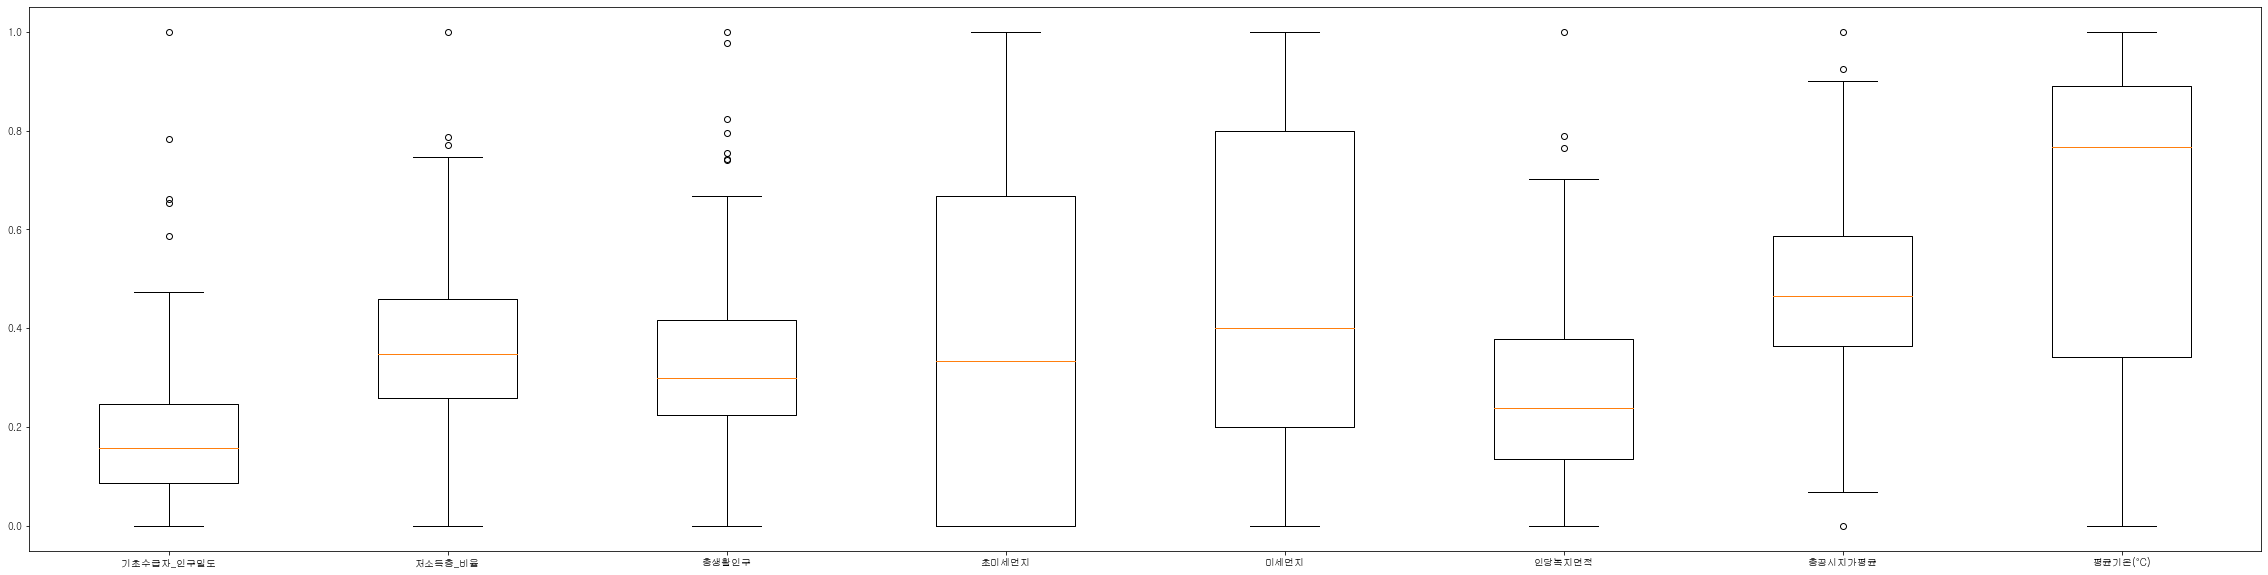

In [37]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,2:]) 

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,2:].columns)

In [36]:
import numpy as np
df['인당녹지면적'] = np.log1p(df['인당녹지면적'])

In [40]:
from sklearn.preprocessing import RobustScaler

robustScaler = RobustScaler()
robustScaled_data = robustScaler.fit_transform(df.iloc[:,2:]) 

{'whiskers': [<matplotlib.lines.Line2D at 0x14b2e769430>,
 'caps': [<matplotlib.lines.Line2D at 0x14b2e7699d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x14b2e769160>,
 'medians': [<matplotlib.lines.Line2D at 0x14b2e769f70>,
 'fliers': [<matplotlib.lines.Line2D at 0x14b2e772280>,
 'means': []}

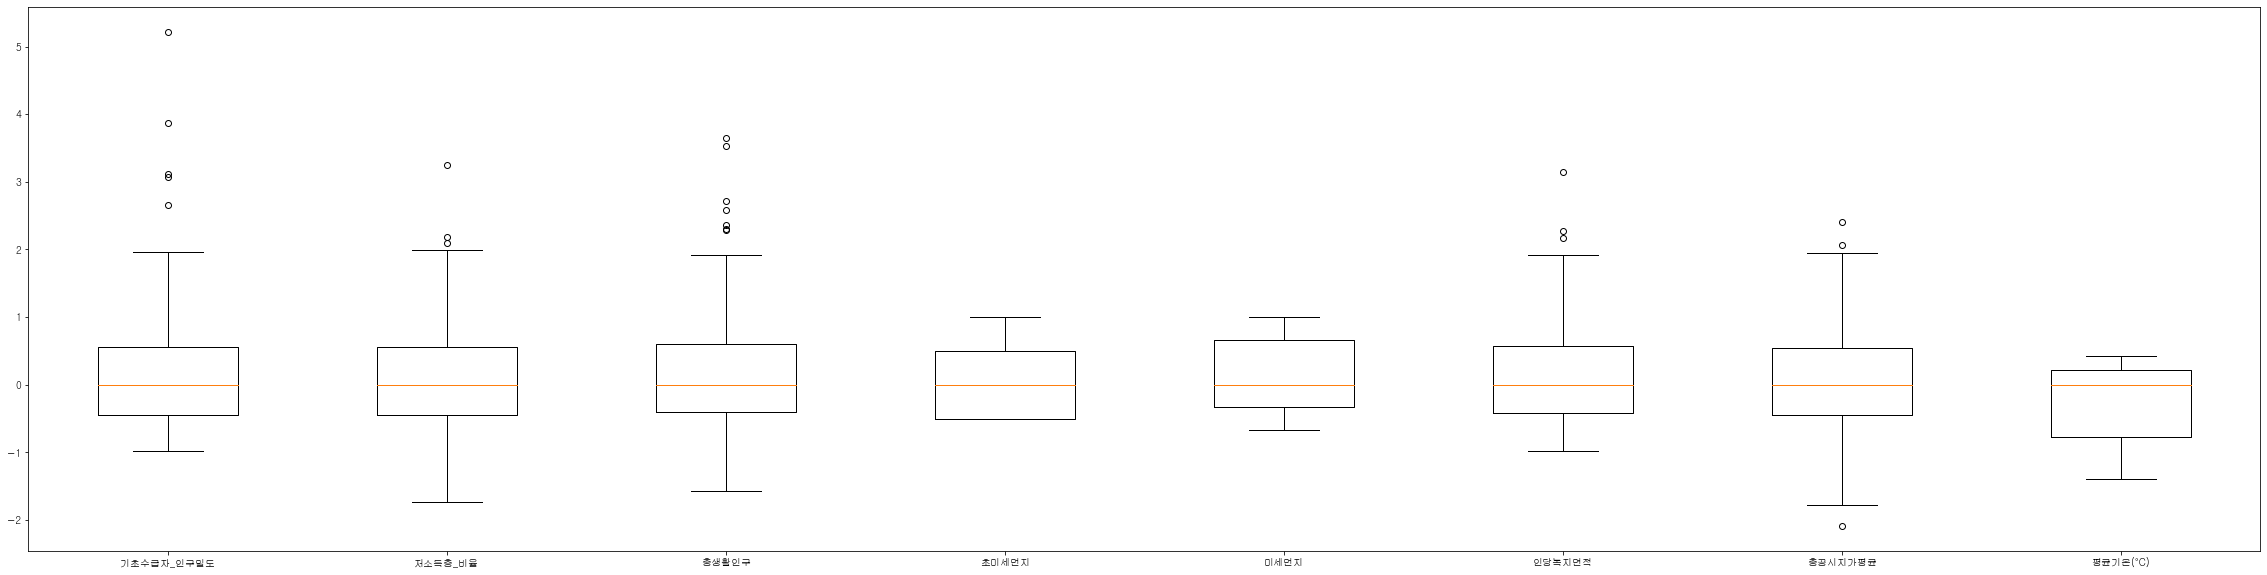

In [41]:
plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(robustScaled_data, labels=df.iloc[:,2:].columns)

# 결과

In [42]:
data_df = pd.DataFrame(minMaxScaled_data,columns = df.iloc[:,2:].columns.to_list())
data_df

,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C)
0,0.191522,0.335542,0.336260,0.0,0.6,0.283271,0.410610,0.767123
1,0.260409,0.280052,0.238526,0.0,0.6,0.688506,0.290138,0.767123
2,0.279518,0.192972,0.149009,0.0,0.6,0.702847,0.295058,0.767123
3,0.367961,0.242605,0.177533,0.0,0.6,0.669652,0.308608,0.767123
4,0.300061,0.483436,0.301709,0.0,0.6,0.180192,0.440083,0.767123
...,...,...,...,...,...,...,...,...
187,0.237849,0.276088,0.376761,0.0,0.4,0.054485,0.541027,0.890411
188,0.110999,0.542238,0.521544,0.0,0.4,0.377058,0.137743,0.890411
189,0.216384,0.326787,0.224939,0.0,0.4,0.360830,0.173439,0.890411
190,0.242133,0.220007,0.226831,0.0,0.4,0.111902,0.456079,0.890411


In [43]:
df_scale = pd.concat([df.iloc[:,:2],data_df], axis=1)

In [44]:
df_scale

,시군구,행정동,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C)
0,강북구,미아동,0.191522,0.335542,0.336260,0.0,0.6,0.283271,0.410610,0.767123
1,강북구,번1동,0.260409,0.280052,0.238526,0.0,0.6,0.688506,0.290138,0.767123
2,강북구,번2동,0.279518,0.192972,0.149009,0.0,0.6,0.702847,0.295058,0.767123
3,강북구,번3동,0.367961,0.242605,0.177533,0.0,0.6,0.669652,0.308608,0.767123
4,강북구,삼각산동,0.300061,0.483436,0.301709,0.0,0.6,0.180192,0.440083,0.767123
...,...,...,...,...,...,...,...,...,...,...
187,중랑구,상봉2동,0.237849,0.276088,0.376761,0.0,0.4,0.054485,0.541027,0.890411
188,중랑구,신내1동,0.110999,0.542238,0.521544,0.0,0.4,0.377058,0.137743,0.890411
189,중랑구,신내2동,0.216384,0.326787,0.224939,0.0,0.4,0.360830,0.173439,0.890411
190,중랑구,중화1동,0.242133,0.220007,0.226831,0.0,0.4,0.111902,0.456079,0.890411


In [45]:
df_scale.to_csv('data/정제데이터/동별데이터_스케일링.csv',encoding='cp949',index=False)